In [1]:
import duckdb
from functions.evaluation import evaluate
from networks.cnn_large_batchnorm import CNNModel
from networks.cnn_network import build_dataloaders


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()

df = df[
    (df['fractions'].apply(len) == 6) &
    (df['boundaries'].apply(len) == 12)
]

train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.5).index


train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

CNN = CNNModel()
cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)
CNN.retrain(cnn_train_dl,cnn_val_dl,patience=15)

Antal utan m-komponent i träningsdatan: 30492
Antal med m-komponent i träningsdatan: 4730
Epoch   0 | train: 0.4087 | val: 0.6298 | acc: 59.58% | AUC: 0.952
  -> ny bästa modell sparad till ../models/convolution_model_larger.pth
Epoch   1 | train: 0.2092 | val: 0.3819 | acc: 80.80% | AUC: 0.978
  -> ny bästa modell sparad till ../models/convolution_model_larger.pth
Epoch   2 | train: 0.1746 | val: 0.1438 | acc: 95.41% | AUC: 0.986
  -> ny bästa modell sparad till ../models/convolution_model_larger.pth
Epoch   3 | train: 0.1550 | val: 1.2405 | acc: 26.41% | AUC: 0.985
Epoch   4 | train: 0.1330 | val: 0.1792 | acc: 98.04% | AUC: 0.987
Epoch   5 | train: 0.1344 | val: 0.2262 | acc: 89.35% | AUC: 0.990
Epoch   6 | train: 0.1106 | val: 0.1087 | acc: 96.51% | AUC: 0.993
  -> ny bästa modell sparad till ../models/convolution_model_larger.pth
Epoch   7 | train: 0.1060 | val: 0.0835 | acc: 97.58% | AUC: 0.995
  -> ny bästa modell sparad till ../models/convolution_model_larger.pth
Epoch   8 | tr

              precision    recall  f1-score   support

     Negativ       0.99      0.98      0.99      7146
     Positiv       0.83      0.94      0.88       586

    accuracy                           0.98      7732
   macro avg       0.91      0.96      0.93      7732
weighted avg       0.98      0.98      0.98      7732

[[7032  114]
 [  37  549]]
AUC: 0.9892424125193788
Accuracy:  98.05%
FN-rate:   6.31%  (farliga missade fall)
FP-rate:   1.60%  (onödiga larm)
Sensitivitet:   93.69%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   98.40%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9892


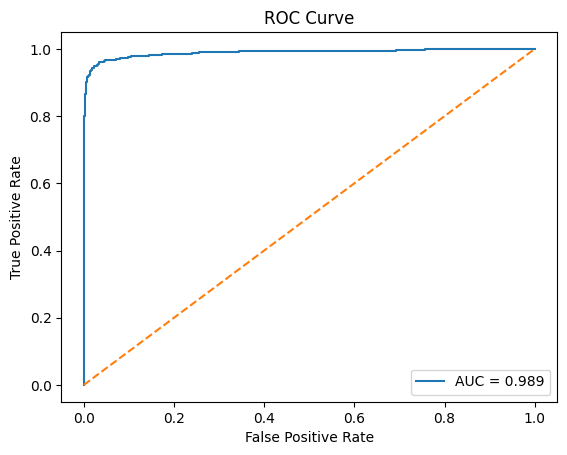

In [2]:
test_rows = test_rows[test_rows['label'].isin([0,1])]
result = CNN.predict(test_rows)
_ = evaluate(result,threshold=0.5,proportion=70)